In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Physical Parameters
E = 2e10     # Pa
NU = 0.1    
R = 5       # m
h = 0.2    # m
phi_0 = 1e-6        # Start near the apex (avoiding exactly 0 for div by zero)
phi_L = np.pi / 2   # End at the equator (90 degrees)
theta_0 = 0.0
theta_L = 2 * np.pi

gamma_c = 24e3
g = gamma_c * h

Cm = (E * h) / (1 - NU**2)

# Hyperparameters
epochs = 5000
lr = 0.001
num_interior = 50
num_boundary = 100

# Penalty
lamb_bc = 1

In [3]:
# Non-dimensionalization
w0 = (gamma_c * R**2) / E
Pi_0 = Cm * (w0 / R)**2

# Some arrays
previous_loss = float('inf')
loss_history = []


In [4]:
def grad(f, v):
    return torch.autograd.grad(f, v, grad_outputs=torch.ones_like(f), create_graph=True)[0]

In [5]:
# 1. Neural Network Architecture
class MembraneHemispherePINN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size)
        )
        
    def forward(self, phi):
        output = self.network(phi**2)
        hard_term = phi * ((np.pi / 2.0)**2 - phi**2)
        u_bar = hard_term * output[:, 0:1]
        w_bar = output[:, 1:2]
        u = u_bar * w0
        w = w_bar * w0
        return u , w

1. The Physics of the Apex (Even vs. Odd Symmetry)

Imagine standing at the exact top center of the hemispherical dome ($\phi = 0$). Because the geometry and the load (self-weight) are perfectly symmetric:
- The Radial Deflection ($w$): If you walk a tiny bit to the left ($-\phi$) or a tiny bit to the right ($+\phi$), the dome must deflect downward by the exact same amount. Therefore, $w(-\phi) = w(\phi)$. This makes $w$ a perfectly Even function. Because it is smooth and symmetric, its slope at the top must be exactly zero: $dw/d\phi = 0$.
- The Meridional Displacement ($u$): This is the displacement sliding away from the top. If you walk right ($+\phi$), $u$ is positive. If you walk left ($-\phi$), "away" is now the negative direction, so $u(-\phi) = -u(\phi)$. This makes $u$ a perfectly Odd function. At the exact center, you cannot slide away in two opposite directions at once, so $u(0) = 0$.

2. The Mathematics of feeding $\phi^2$

A standard Neural Network (let's call it $NN$) is just a universal function approximator. If you feed it $\phi$, it outputs some arbitrary curve $NN(\phi)$. The optimizer tries to make $NN'(0) = 0$, but it will never be mathematically exact.Now, look what happens when we feed $\phi^2$ into the network. The output becomes a composite function: $F(\phi) = NN(\phi^2)$.Let's take the derivative using the Chain Rule:
$$\frac{dF}{d\phi} = NN'(\phi^2) \cdot \frac{d}{d\phi}(\phi^2)$$
$$\frac{dF}{d\phi} = NN'(\phi^2) \cdot 2\phi$$
Now, evaluate the slope at the apex ($\phi = 0$):
$$\frac{dF}{d\phi}\Big|_{\phi=0} = NN'(0) \cdot 2(0) = \mathbf{0}$$
The Magic: No matter what weights and biases the Neural Network learns during training, the output $F(\phi)$ is mathematically guaranteed to have a perfectly flat slope at $\phi = 0$. It forces the network to only generate Even functions.

3. Constructing the Perfect Outputs

In your updated forward function, we used this to build the exact physics into the network:
- out = self.net(phi**2) $\leftarrow$ This base output is now perfectly EVEN.
- w_hat = out[:, 1] $\leftarrow$ We use the even output directly for $w$. The slope is mathematically forced to be 0 at the apex.
- u_hat = phi * (...) * out[:, 0] $\leftarrow$ By multiplying an Even function by $\phi$ (which is an Odd function), $u$ becomes perfectly ODD. This mathematically guarantees $u=0$ at the apex.

In [6]:
# 2. Potential Energy and BC Loss Functions
def energy_loss(model, coords):
    # Get coordinates and Enable gradient tracking
    x1 = coords[:, 0:1].requires_grad_(True)
    
    # Forward pass
    u, w = model(x1)
    
    # Gradients
    u_prime = grad(u, x1)
    
    # Hemisphere Geometry
    A = R
    R1 = R
    R2 = R
    r = R * torch.sin(x1)
    r_prime = R * torch.cos(x1)
    
    # Membrane Strains
    e11 = (1/A) * u_prime + (w/R1)
    e22 = (r_prime / (r*A)) * u + (w/R2)

    # Constitutive Equations
    n11 = Cm * (e11 + NU*e22)
    n22 = Cm * (e22 + NU*e11)
    
    # Energy
    U_density = 0.5 * (n11*e11 + n22*e22)

    p_1 = g * torch.sin(x1)
    p_n = -g * torch.cos(x1)
    W_density = p_1*u + p_n*w
    
    # Area
    dOmega = A * r

    # Total
    Pi_density = (U_density - W_density) * dOmega / Pi_0
    return torch.mean(Pi_density)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MembraneHemispherePINN(1, 2, 64).to(device)

# Training Loop
print("Starting training...")

# --- PHASE 1: ADAM OPTIMIZER ---
optimizer_adam = optim.Adam(model.parameters(), lr=2e-3)
print("Phase 1: Adam Optimizer (Finding the neighborhood)")
for epoch in range(epochs+1):
    optimizer_adam.zero_grad()

    # Generate Points
    # Interior (Collocation)
    phi_col = torch.empty(num_interior, 1, device=device).uniform_(phi_0, phi_L)
    coords = torch.cat([phi_col], dim=1)

    # Physics loss (Energy minimization)
    loss_energy = energy_loss(model, coords)
    total_loss = loss_energy

    total_loss.backward()
    optimizer_adam.step()
    
    current_loss = total_loss.item()
    loss_history.append(current_loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Energy: {current_loss}")
    
    # Convergence Check
    if epoch > 0:
        relative_error = abs(previous_loss - current_loss) / abs(current_loss + 1e-15)
        if relative_error < 1e-20:
            print(f"Convergent at epoch {epoch}. Relative error: {relative_error}")
            break
    
    previous_loss = current_loss    

# --- PHASE 2: L-BFGS OPTIMIZER ---
print("\nPhase 2: L-BFGS Optimizer (High-precision polishing)")
# L-BFGS requires a static set of points during its line search closure
phi_static = torch.linspace(phi_0, phi_L, 2500, device=device).unsqueeze(1)

optimizer_lbfgs = optim.LBFGS(model.parameters(), 
                                max_iter=3000, 
                                tolerance_grad=1e-7, 
                                tolerance_change=1e-9, 
                                history_size=100,
                                line_search_fn="strong_wolfe")

def closure():
    optimizer_lbfgs.zero_grad()
    loss = energy_loss(model, phi_static)
    loss.backward()
    return loss
    
optimizer_lbfgs.step(closure)

# Print final loss after L-BFGS
final_loss = energy_loss(model, phi_static)
print(f"  Final L-BFGS Energy Loss: {final_loss.item():.6e}\n")

Starting training...
Phase 1: Adam Optimizer (Finding the neighborhood)
Epoch 0 | Energy: 2.606152296066284
Epoch 500 | Energy: -6.515994071960449
Epoch 1000 | Energy: -3.99479603767395
Epoch 1500 | Energy: -3.854336738586426
Epoch 2000 | Energy: -4.829492092132568
Epoch 2500 | Energy: -5.140141010284424
Epoch 3000 | Energy: -7.686063289642334
Epoch 3500 | Energy: -3.029998540878296
Epoch 4000 | Energy: -5.974648475646973
Epoch 4500 | Energy: -3.4402952194213867
Epoch 5000 | Energy: -5.118627548217773

Phase 2: L-BFGS Optimizer (High-precision polishing)
  Final L-BFGS Energy Loss: -5.965862e+00



In [8]:
device = next(model.parameters()).device
model.eval() # Set to evaluation mode

angles = [phi_0, np.pi / 4.0, np.pi / 2.0]

print(f"\n==========================================================================================")
print(f"Results for Membrane Forces under Self-Weight")
print(f"==========================================================================================")
print(f"{'Angle':<10} | {'Force':<15} | {'Numerical (PINN)':<20} | {'Analytical (Exact)':<20} | {'Error (%)'}")
print(f"------------------------------------------------------------------------------------------")

for ang in angles:
# The top center point (apex)
    phi_t = torch.tensor([[ang]], dtype=torch.float32, device=device, requires_grad=True)

    u, w = model(phi_t)

    # We need to compute the derivative u_prime to get the strains
    u_prime = torch.autograd.grad(u, phi_t, grad_outputs=torch.ones_like(u))[0]

    A = R
    R1 = R
    R2 = R
    r = R * torch.sin(phi_t)
    r_prime = R * torch.cos(phi_t)

    # Kinematic equations
    e11 = (1.0 / A) * u_prime + (w / R1)
    e22 = (r_prime / (r * A)) * u + (w / R2)

    # Constitutive equations
    n11 = Cm * (e11 + NU * e22)
    n22 = Cm * (e22 + NU * e11)

    # Extract numerical scalar values and convert them to numpy arrays
    n11_num = n11.detach().cpu().numpy().squeeze()
    n22_num = n22.detach().cpu().numpy().squeeze()

    # Calculate exact analytical solutions
    # w_exact = np.array(-gamma_c * R**2 * (1 - NU) / (2 * E))
    cos_phi = np.cos(ang)
    sin_phi = np.sin(ang)
    n11_exact = - (g * R) / (1.0 + cos_phi)
    n22_exact = -(g * R * (cos_phi - sin_phi**2)) / (1 + cos_phi)

    # Compute error percentages
    err_n11 = abs((n11_num - n11_exact) / n11_exact) * 100 if abs(n11_exact)>1e-3 else 0
    err_n22 = abs((n22_num - n22_exact) / n22_exact) * 100 if abs(n22_exact)>1e-3 else 0

    deg = round(180 * ang/(np.pi), 4)

    # Print formatted comparison row for this angle
    print(f"{deg:<10} | {'n_phi (n_11)':<15} | {n11_num:<20.6e} | {n11_exact:<20.6e} | {err_n11:.4f}%")
    print(f"{'':<10} | {'n_theta (n_22)':<15} | {n22_num:<20.6e} | {n22_exact:<20.6e} | {err_n22:.4f}%")
    print(f"------------------------------------------------------------------------------------------")
print(f"==========================================================================================\n")


Results for Membrane Forces under Self-Weight
Angle      | Force           | Numerical (PINN)     | Analytical (Exact)   | Error (%)
------------------------------------------------------------------------------------------
0.0001     | n_phi (n_11)    | -1.191520e+04        | -1.200000e+04        | 0.7067%
           | n_theta (n_22)  | -1.191520e+04        | -1.200000e+04        | 0.7067%
------------------------------------------------------------------------------------------
45.0       | n_phi (n_11)    | -1.411726e+04        | -1.405887e+04        | 0.4153%
           | n_theta (n_22)  | -2.925214e+03        | -2.911688e+03        | 0.4645%
------------------------------------------------------------------------------------------
90.0       | n_phi (n_11)    | -2.383441e+04        | -2.400000e+04        | 0.6900%
           | n_theta (n_22)  | 2.381374e+04         | 2.400000e+04         | 0.7761%
-----------------------------------------------------------------------------------

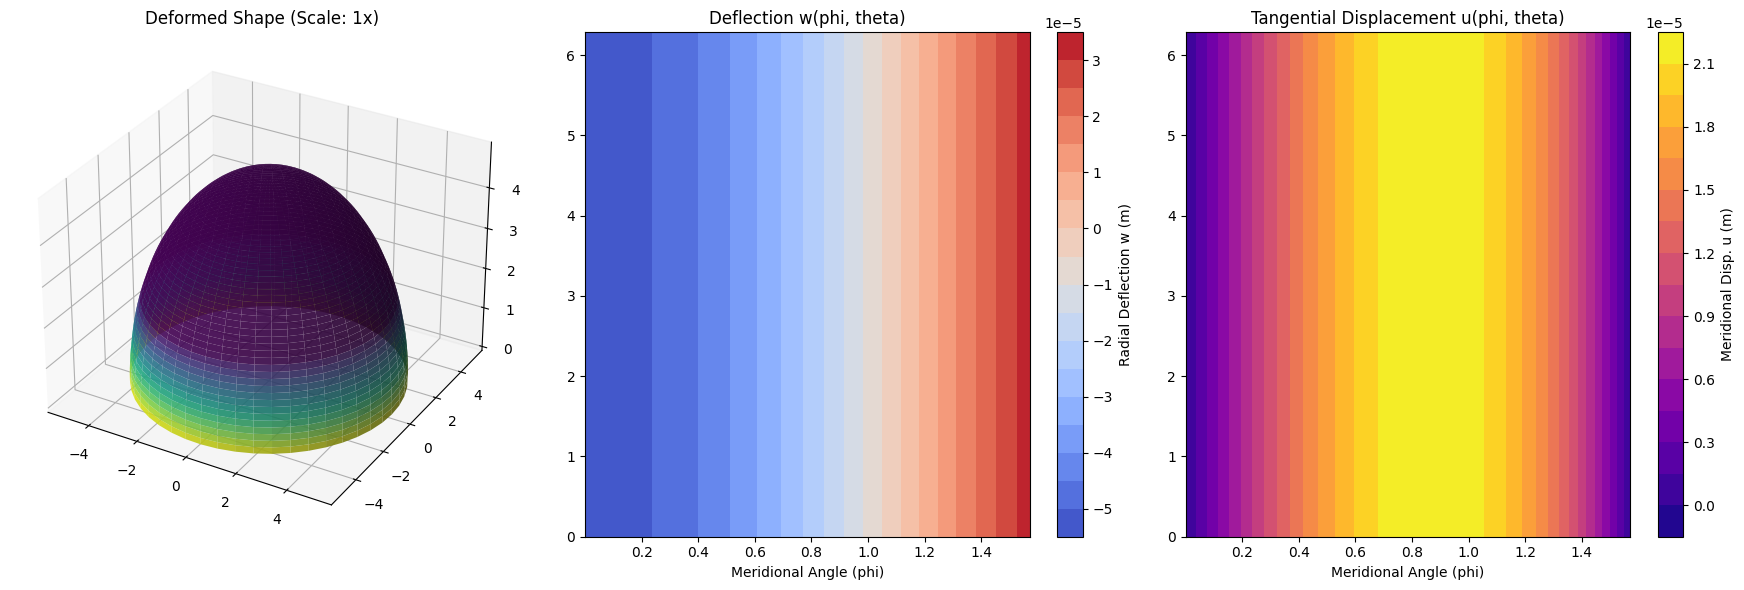

In [9]:
# 4. Visualization
scale_factor=1

device = next(model.parameters()).device
model.eval()

phi_vec = np.linspace(phi_0, phi_L, num_interior)
theta_vec = np.linspace(theta_0, theta_L, num_interior)
PHI, THETA = np.meshgrid(phi_vec, theta_vec)

phi_t = torch.tensor(PHI.flatten().reshape(-1, 1), dtype=torch.float32, device=device)
theta_t = torch.tensor(THETA.flatten().reshape(-1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    u_pred, w_pred = model(phi_t)
    u_pred = u_pred.cpu().numpy().reshape(num_interior, num_interior)
    w_pred = w_pred.cpu().numpy().reshape(num_interior, num_interior)

X = R * np.sin(PHI) * np.cos(THETA)
Y = R * np.sin(PHI) * np.sin(THETA)
Z = R * np.cos(PHI)
    
X_def = (R + w_pred * scale_factor) * np.sin(PHI) * np.cos(THETA)
Y_def = (R + w_pred * scale_factor) * np.sin(PHI) * np.sin(THETA)
Z_def = (R + w_pred * scale_factor) * np.cos(PHI)


fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X_def, Y_def, Z_def, facecolors=plt.cm.viridis(w_pred / np.max(w_pred)), 
                        edgecolor='none', alpha=0.9)
ax1.set_title(f"Deformed Shape (Scale: {scale_factor}x)")

ax2 = fig.add_subplot(132)
cp2 = ax2.contourf(PHI, THETA, w_pred, cmap='coolwarm', levels=20)
fig.colorbar(cp2, ax=ax2).set_label('Radial Deflection w (m)')
ax2.set_title("Deflection w(phi, theta)")
ax2.set_xlabel("Meridional Angle (phi)")

ax3 = fig.add_subplot(133)
cp3 = ax3.contourf(PHI, THETA, u_pred, cmap='plasma', levels=20)
fig.colorbar(cp3, ax=ax3).set_label('Meridional Disp. u (m)')
ax3.set_title("Tangential Displacement u(phi, theta)")
ax3.set_xlabel("Meridional Angle (phi)")

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


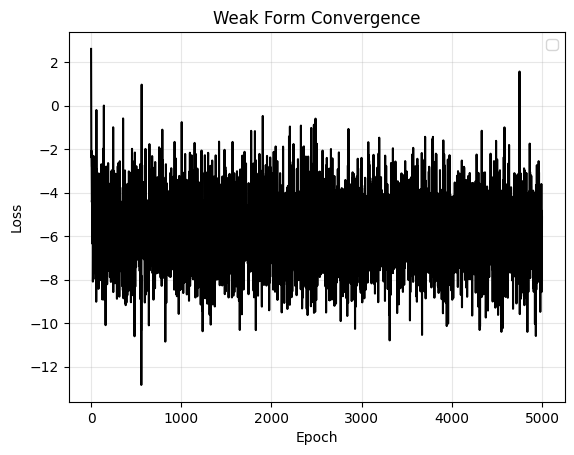

In [10]:
plt.plot(loss_history, color='black')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Weak Form Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()